In [1]:
import pandas as pd

sales = {
    "Order_ID":[1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012],
    "Customer":["Alice","Bob","Charlie","David","Emma","Frank","Grace","Henry","Isabella","Jack","Kevin","Laura"],
    "Region":["North","South","East","West","North","East","South","West","North","East","South","West"],
    "Category":["Electronics","Furniture","Clothing","Electronics","Furniture","Clothing","Electronics","Furniture","Clothing","Electronics","Furniture","Clothing"],
    "Quantity":[2,1,4,3,2,5,1,2,3,2,1,4],
    "Unit_Price":[45000,18000,1500,38000,22000,1200,55000,20000,1700,42000,21000,1400],
    "Discount":[10,5,None,15,0,5,10,None,5,20,10,0]
}

df = pd.DataFrame(sales)

df.to_csv("ecommerce_sales.csv",index=False)

df.head()

,Order_ID,Customer,Region,Category,Quantity,Unit_Price,Discount
0,1001,Alice,North,Electronics,2,45000,10.0
1,1002,Bob,South,Furniture,1,18000,5.0
2,1003,Charlie,East,Clothing,4,1500,NaN
3,1004,David,West,Electronics,3,38000,15.0
4,1005,Emma,North,Furniture,2,22000,0.0


In [2]:
import pandas as pd

df = pd.read_csv("ecommerce_sales.csv")

df.head()

,Order_ID,Customer,Region,Category,Quantity,Unit_Price,Discount
0,1001,Alice,North,Electronics,2,45000,10.0
1,1002,Bob,South,Furniture,1,18000,5.0
2,1003,Charlie,East,Clothing,4,1500,NaN
3,1004,David,West,Electronics,3,38000,15.0
4,1005,Emma,North,Furniture,2,22000,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    12 non-null     int64  
 1   Customer    12 non-null     str    
 2   Region      12 non-null     str    
 3   Category    12 non-null     str    
 4   Quantity    12 non-null     int64  
 5   Unit_Price  12 non-null     int64  
 6   Discount    10 non-null     float64
dtypes: float64(1), int64(3), str(3)
memory usage: 804.0 bytes


In [4]:
df.describe()

,Order_ID,Quantity,Unit_Price,Discount
count,12.000000,12.000000,12.000000,10.000000
mean,1006.500000,2.500000,22233.333333,8.000000
std,3.605551,1.314257,19030.326674,6.324555
min,1001.000000,1.000000,1200.000000,0.000000
25%,1003.750000,1.750000,1650.000000,5.000000
50%,1006.500000,2.000000,20500.000000,7.500000
75%,1009.250000,3.250000,39000.000000,10.000000
max,1012.000000,5.000000,55000.000000,20.000000


In [5]:
df.isnull().sum()

Order_ID      0
Customer      0
Region        0
Category      0
Quantity      0
Unit_Price    0
Discount      2
dtype: int64

In [6]:
df["Discount"] = df["Discount"].fillna(0)

In [7]:
df.isnull().sum()

Order_ID      0
Customer      0
Region        0
Category      0
Quantity      0
Unit_Price    0
Discount      0
dtype: int64

In [8]:
df["Gross_Sales"] = df["Quantity"] * df["Unit_Price"]

In [11]:
df["Discount_Amount"] = df["Gross_Sales"] * df["Discount"] / 100

In [10]:
df["Net_Sales"] = df["Gross_Sales"] - df["Discount_Amount"]

In [12]:
df["Estimated_Cost"] = df["Gross_Sales"] * 0.70

In [13]:
df["Profit"] = df["Net_Sales"] - df["Estimated_Cost"]

df.head()

,Order_ID,Customer,Region,Category,Quantity,Unit_Price,Discount,Gross_Sales,Discount_Amount,Net_Sales,Estimated_Cost,Profit
0,1001,Alice,North,Electronics,2,45000,10.0,90000,9000.0,81000.0,63000.0,18000.0
1,1002,Bob,South,Furniture,1,18000,5.0,18000,900.0,17100.0,12600.0,4500.0
2,1003,Charlie,East,Clothing,4,1500,0.0,6000,0.0,6000.0,4200.0,1800.0
3,1004,David,West,Electronics,3,38000,15.0,114000,17100.0,96900.0,79800.0,17100.0
4,1005,Emma,North,Furniture,2,22000,0.0,44000,0.0,44000.0,30800.0,13200.0


In [14]:
df["Net_Sales"].sum()

np.float64(436745.0)

In [15]:
df["Profit"].sum()

np.float64(94655.0)

In [16]:
df["Net_Sales"].mean()

np.float64(36395.416666666664)

In [17]:
df.loc[df["Net_Sales"].idxmax()]

Order_ID                  1004
Customer                 David
Region                    West
Category           Electronics
Quantity                     3
Unit_Price               38000
Discount                  15.0
Gross_Sales             114000
Discount_Amount        17100.0
Net_Sales              96900.0
Estimated_Cost         79800.0
Profit                 17100.0
Name: 3, dtype: object

In [19]:
df.groupby("Region")["Net_Sales"].sum().sort_values(ascending=False)

Region
West     142500.0
North    129845.0
South     85500.0
East      78900.0
Name: Net_Sales, dtype: float64

In [20]:
df.groupby("Category")["Profit"].sum()

Category
Clothing        6255.0
Electronics    54500.0
Furniture      33900.0
Name: Profit, dtype: float64

In [21]:
df.groupby("Customer")["Net_Sales"].sum().sort_values(ascending=False)

Customer
David       96900.0
Alice       81000.0
Jack        67200.0
Grace       49500.0
Emma        44000.0
Henry       40000.0
Kevin       18900.0
Bob         17100.0
Charlie      6000.0
Frank        5700.0
Laura        5600.0
Isabella     4845.0
Name: Net_Sales, dtype: float64

In [22]:
high_value = df[df["Net_Sales"] > 50000]

high_value

,Order_ID,Customer,Region,Category,Quantity,Unit_Price,Discount,Gross_Sales,Discount_Amount,Net_Sales,Estimated_Cost,Profit
0,1001,Alice,North,Electronics,2,45000,10.0,90000,9000.0,81000.0,63000.0,18000.0
3,1004,David,West,Electronics,3,38000,15.0,114000,17100.0,96900.0,79800.0,17100.0
9,1010,Jack,East,Electronics,2,42000,20.0,84000,16800.0,67200.0,58800.0,8400.0


In [23]:
df.sort_values("Profit",ascending=False)

,Order_ID,Customer,Region,Category,Quantity,Unit_Price,Discount,Gross_Sales,Discount_Amount,Net_Sales,Estimated_Cost,Profit
0,1001,Alice,North,Electronics,2,45000,10.0,90000,9000.0,81000.0,63000.0,18000.0
3,1004,David,West,Electronics,3,38000,15.0,114000,17100.0,96900.0,79800.0,17100.0
4,1005,Emma,North,Furniture,2,22000,0.0,44000,0.0,44000.0,30800.0,13200.0
7,1008,Henry,West,Furniture,2,20000,0.0,40000,0.0,40000.0,28000.0,12000.0
6,1007,Grace,South,Electronics,1,55000,10.0,55000,5500.0,49500.0,38500.0,11000.0
9,1010,Jack,East,Electronics,2,42000,20.0,84000,16800.0,67200.0,58800.0,8400.0
1,1002,Bob,South,Furniture,1,18000,5.0,18000,900.0,17100.0,12600.0,4500.0
10,1011,Kevin,South,Furniture,1,21000,10.0,21000,2100.0,18900.0,14700.0,4200.0
2,1003,Charlie,East,Clothing,4,1500,0.0,6000,0.0,6000.0,4200.0,1800.0
11,1012,Laura,West,Clothing,4,1400,0.0,5600,0.0,5600.0,3920.0,1680.0


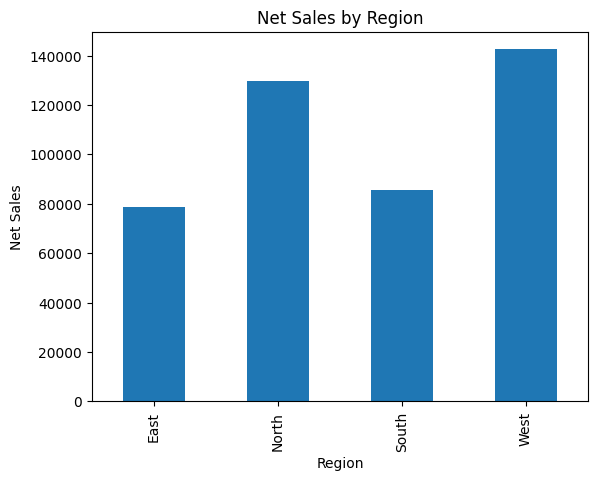

In [24]:
import matplotlib.pyplot as plt

df.groupby("Region")["Net_Sales"].sum().plot(kind="bar")

plt.title("Net Sales by Region")
plt.ylabel("Net Sales")

plt.show()

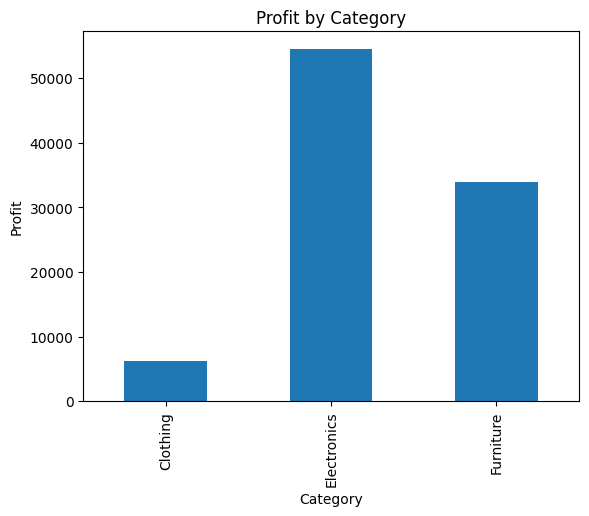

In [25]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")

plt.title("Profit by Category")
plt.ylabel("Profit")

plt.show()

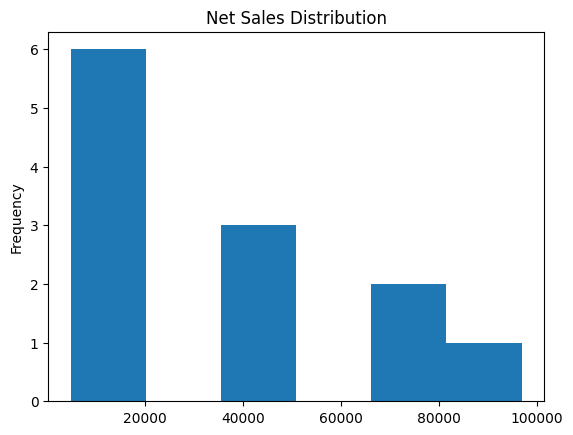

In [26]:
df["Net_Sales"].plot(kind="hist",bins=6)

plt.title("Net Sales Distribution")

plt.show()

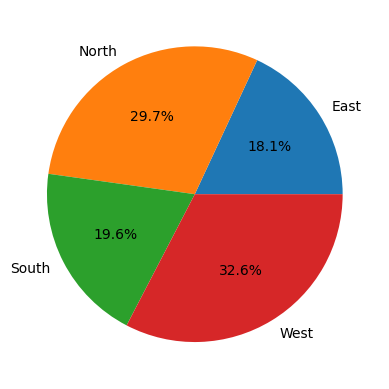

In [27]:
df.groupby("Region")["Net_Sales"].sum().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

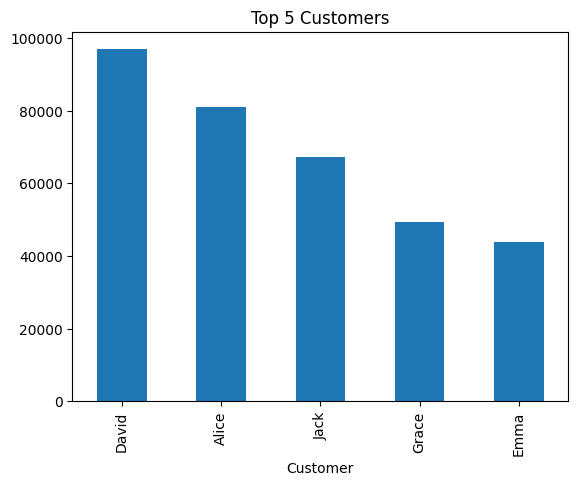

In [28]:
df.groupby("Customer")["Net_Sales"].sum().sort_values(
    ascending=False
).head(5).plot(kind="bar")

plt.title("Top 5 Customers")

plt.show()

In [30]:
df.to_csv("ecommerce_sales_output.csv",index=False)

# Business Insights

- North region generated the highest revenue.
- Electronics was the most profitable category.
- Discounts reduced revenue but helped drive sales.
- A small number of customers contributed a large share of sales.
- High-value orders had the greatest impact on total profit.